## LSTM External force estimation regarding PSM1 OR PSM2.

In [1]:
import os
import sys
import time as tm
import math
import copy
import argparse
from pathlib import Path
from os.path import join, exists

import numpy as np
import matplotlib.pyplot as plt
import tqdm
from scipy import interpolate
from scipy.signal import lfilter
from rosbags.rosbag1 import Reader
from rosbags.typesys import Stores, get_typestore


Read bags

In [2]:
from pathlib import Path
import os
import numpy as np
from scipy import interpolate

# rosbags: pure Python, no ROS installation needed (pip install rosbags)
from rosbags.rosbag1 import Reader
from rosbags.typesys import Stores, get_typestore

_typestore = get_typestore(Stores.ROS1_NOETIC)

def _read_topic(bag_path, topic):
    """Read all messages on a topic from a ROS1 bag file. Returns (timestamps, msgs)."""
    timestamps, msgs = [], []
    with Reader(bag_path) as reader:
        connections = [c for c in reader.connections if c.topic == topic]
        if not connections:
            return timestamps, msgs
        for connection, timestamp, rawdata in reader.messages(connections=connections):
            timestamps.append(timestamp * 1e-9)  # nanoseconds to seconds
            msgs.append(_typestore.deserialize_ros1(rawdata, connection.msgtype))
    return timestamps, msgs

class RosbagParser:

    def __init__(self, folder, output, prefix="", index=0):
        self.folder = Path(folder)
        self.output = Path(output)
        self.prefix = prefix
        self.index = index

        self.output.mkdir(parents=True, exist_ok=True)

    def interp(self, time, mat):
        new_mat = np.zeros((len(time), mat.shape[1]))
        new_mat[:, 0] = time
        for i in range(mat.shape[1]):
            f = interpolate.interp1d(mat[:, 0], mat[:, i])
            new_mat[:, i] = f(time)
        return new_mat

    def single_datapoint_processing(self, file_name):
        bag_path = self.folder / file_name

        force_sensor = []
        force_sensor_timestamps = []
        joint_position = []
        joint_velocity = []
        joint_effort = []
        joint_timestamps = []
        jacobian = []
        jacobian_timestamps = []
        jaw = []
        jaw_timestamps = []

        print("Processing " + file_name)

        # --- measured_js ---
        ts_list, msgs = _read_topic(str(bag_path), '/PSM1/measured_js')
        for ts, msg in zip(ts_list, msgs):
            if len(msg.position) == 0:
                continue
            joint_timestamps.append(ts)
            joint_velocity.append(list(msg.velocity))
            joint_position.append(list(msg.position))
            joint_effort.append(list(msg.effort))

        if len(joint_timestamps) == 0:
            print(f"Skipped {file_name}: no /PSM1/measured_js data found.")
            return

        # --- spatial jacobian ---
        ts_list, msgs = _read_topic(str(bag_path), '/PSM1/spatial/jacobian')
        for ts, msg in zip(ts_list, msgs):
            jacobian_timestamps.append(ts)
            jacobian.append(list(msg.data))

        # --- jaw measured_js ---
        ts_list, msgs = _read_topic(str(bag_path), '/PSM1/jaw/measured_js')
        for ts, msg in zip(ts_list, msgs):
            if len(msg.position) == 0:
                continue
            jaw_timestamps.append(ts)
            jaw.append([msg.position[0], msg.velocity[0], msg.effort[0]])

        # --- force sensor ---
        ts_list, msgs = _read_topic(str(bag_path), '/measured_cf')
        for ts, msg in zip(ts_list, msgs):
            force_sensor_timestamps.append(ts)
            force_sensor.append([
                msg.wrench.force.x,
                msg.wrench.force.y,
                msg.wrench.force.z,
                msg.wrench.torque.x,
                msg.wrench.torque.y,
                msg.wrench.torque.z,
            ])

        print("Processed wrench: counts: {}".format(len(force_sensor_timestamps)))
        print("Processed state joint current: count: {}".format(len(joint_timestamps)))
        print("Processed state jaw current: count: {}".format(len(jaw_timestamps)))
        print("Processed Jacobian: count: {}".format(len(jacobian)))

        # --- create output directories ---
        joints_dir = self.output / "joints"
        jacobian_dir = self.output / "jacobian"
        sensor_dir = self.output / "sensor"
        jaw_dir = self.output / "jaw"

        joints_dir.mkdir(parents=True, exist_ok=True)
        jacobian_dir.mkdir(parents=True, exist_ok=True)

        if len(force_sensor) > 0:
            sensor_dir.mkdir(parents=True, exist_ok=True)

        if len(jaw) > 0:
            jaw_dir.mkdir(parents=True, exist_ok=True)

        # --- time normalization and array construction ---
        start_time = joint_timestamps[0]

        joint_timestamps = np.array(joint_timestamps) - start_time

        joints = np.column_stack((
            joint_timestamps,
            joint_position,
            joint_velocity,
            joint_effort
        ))

        if len(jacobian) > 0:
            jacobian_timestamps = np.array(jacobian_timestamps) - start_time
            jacobian = np.column_stack((jacobian_timestamps, jacobian))
        else:
            jacobian = None

        if len(force_sensor) > 0:
            force_sensor_timestamps = np.array(force_sensor_timestamps) - start_time
            force_sensor = np.column_stack((force_sensor_timestamps, force_sensor))
        else:
            force_sensor = None

        if len(jaw) > 0:
            jaw_timestamps = np.array(jaw_timestamps) - start_time
            jaw = np.squeeze(np.array(jaw))
            jaw = np.column_stack((jaw_timestamps, jaw))

            if len(joints) < len(jaw):
                jaw = jaw[0:len(joints), :]
            else:
                joints = joints[0:len(jaw), :]
        else:
            jaw = None

        # --- save CSVs ---
        out_name = self.prefix + str(self.index)

        np.savetxt(joints_dir / f"{out_name}.csv", joints, delimiter=',')

        if jacobian is not None:
            np.savetxt(jacobian_dir / f"{out_name}.csv", jacobian, delimiter=',')

        if force_sensor is not None:
            np.savetxt(sensor_dir / f"{out_name}.csv", force_sensor, delimiter=',')

        if jaw is not None:
            np.savetxt(jaw_dir / f"{out_name}.csv", jaw, delimiter=',')

        print("Wrote out " + out_name)
        print("")

    def parse_bags(self):
        print("\nParsing\n")

        files = sorted(os.listdir(self.folder))

        for file_name in files:
            if file_name.endswith('.bag'):
                self.single_datapoint_processing(file_name)
                self.index += 1

In [3]:
data = os.path.join('..', 'Data')

train_path = os.path.join(data, 'train')
val_path   = os.path.join(data, 'val')
test_path  = os.path.join(data, 'test')

train_out = os.path.join(data, 'train_csv')
val_out   = os.path.join(data, 'val_csv')
test_out  = os.path.join(data, 'test_csv')

In [4]:
parser = RosbagParser(
    folder=train_path,
    output=train_out,
    prefix="data_",
    index=0
)
parser.parse_bags()

parser = RosbagParser(
    folder=val_path,
    output=val_out,
    prefix="data_",
    index=0
)
parser.parse_bags()

parser = RosbagParser(
    folder=test_path,
    output=test_out,
    prefix="data_",
    index=0
)
parser.parse_bags()


Parsing

Processing train_fs_1.bag
Processed wrench: counts: 0
Processed state joint current: count: 14975
Processed state jaw current: count: 14975
Processed Jacobian: count: 14975
Wrote out data_0

Processing train_fs_3.bag
Processed wrench: counts: 0
Processed state joint current: count: 18596
Processed state jaw current: count: 18596
Processed Jacobian: count: 18596
Wrote out data_1

Processing train_fs_4.bag
Processed wrench: counts: 40356
Processed state joint current: count: 40357
Processed state jaw current: count: 40357
Processed Jacobian: count: 40357
Wrote out data_2


Parsing

Processing train_fs_0.bag
Processed wrench: counts: 0
Processed state joint current: count: 13589
Processed state jaw current: count: 13590
Processed Jacobian: count: 13589
Wrote out data_0

Processing train_fs_2.bag
Processed wrench: counts: 0
Processed state joint current: count: 16779
Processed state jaw current: count: 16779
Processed Jacobian: count: 16779
Wrote out data_1


Parsing

Processing 

Preprocess

In [4]:
import os
from pathlib import Path

import numpy as np
from scipy import interpolate


def preprocess_csv(path, cut_off=100, dt=0.01):

    path = Path(path)

    joint_path = path / "joints"
    jacobian_path = path / "jacobian"
    jaw_path = path / "jaw"

    all_joints = np.array([])
    all_jacobian = np.array([])
    all_jaw = np.array([])

    csv_files = sorted(
        f for f in os.listdir(joint_path)
        if f.endswith(".csv") and not f.startswith("interpolated")
    )

    for cur_file in csv_files:
        print("Processing:", cur_file)

        joints = np.loadtxt(joint_path / cur_file, delimiter=",")
        jacobian = np.loadtxt(jacobian_path / cur_file, delimiter=",")
        jaw = np.loadtxt(jaw_path / cur_file, delimiter=",")

        end_idx = int(joints.shape[0] / cut_off)

        joints = joints[0:end_idx * cut_off, :]
        jacobian = jacobian[0:end_idx * cut_off, :]
        jaw = jaw[0:end_idx * cut_off, :]

        if joints[0, 0] > 1000:
            joints[:, 0] = joints[:, 0] - joints[0, 0]

        if jacobian[0, 0] > 1000:
            jacobian[:, 0] = jacian[:, 0] - jacobian[0, 0]

        if jaw[0, 0] > 1000:
            jaw[:, 0] = jaw[:, 0] - jaw[0, 0]

        if all_joints.size:
            joints[:, 0] = all_joints[-1, 0] + joints[:, 0] + 0.001

        if all_jacobian.size:
            jacobian[:, 0] = all_jacobian[-1, 0] + jacobian[:, 0] + 0.001

        if all_jaw.size:
            jaw[:, 0] = all_jaw[-1, 0] + jaw[:, 0] + 0.001

        all_joints = np.vstack((all_joints, joints)) if all_joints.size else joints
        all_jacobian = np.vstack((all_jacobian, jacobian)) if all_jacobian.size else jacobian
        all_jaw = np.vstack((all_jaw, jaw)) if all_jaw.size else jaw

    print("all_joints:", all_joints.shape)
    print("all_jacobian:", all_jacobian.shape)
    print("all_jaw:", all_jaw.shape)

    joint_time = all_joints[:, 0] - all_joints[0, 0]
    jacobian_time = all_jacobian[:, 0] - all_joints[0, 0]
    jaw_time = all_jaw[:, 0] - all_joints[0, 0]

    start_time = np.max([joint_time[0], jacobian_time[0], jaw_time[0]])
    end_time = np.min([joint_time[-1], jacobian_time[-1], jaw_time[-1]])

    print("Interpolation time range:", start_time, "to", end_time)

    interpolated_time = np.arange(start_time, end_time, dt)

    # joints: time + 18 columns
    interp_joints = np.zeros((interpolated_time.shape[0], 19))
    interp_joints[:, 0] = interpolated_time

    for i in range(18):
        f = interpolate.interp1d(joint_time, all_joints[:, i + 1])
        interp_joints[:, i + 1] = f(interpolated_time)

    np.savetxt(
        joint_path / "interpolated_all_joints.csv",
        interp_joints,
        delimiter=","
    )

    # jacobian: time + 36 columns
    interp_jacobian = np.zeros((interpolated_time.shape[0], 37))
    interp_jacobian[:, 0] = interpolated_time

    for i in range(36):
        f = interpolate.interp1d(jacobian_time, all_jacobian[:, i + 1])
        interp_jacobian[:, i + 1] = f(interpolated_time)

    np.savetxt(
        jacobian_path / "interpolated_all_jacobian.csv",
        interp_jacobian,
        delimiter=","
    )

    # jaw: time + 3 columns
    interp_jaw = np.zeros((interpolated_time.shape[0], 4))
    interp_jaw[:, 0] = interpolated_time

    for i in range(3):
        f = interpolate.interp1d(jaw_time, all_jaw[:, i + 1])
        interp_jaw[:, i + 1] = f(interpolated_time)

    np.savetxt(
        jaw_path / "interpolated_all_jaw.csv",
        interp_jaw,
        delimiter=","
    )

    print("Saved:")
    print(joint_path / "interpolated_all_joints.csv")
    print(jacobian_path / "interpolated_all_jacobian.csv")
    print(jaw_path / "interpolated_all_jaw.csv")

    return interp_joints, interp_jacobian, interp_jaw

In [6]:
interp_joints_train, interp_jacobian_train, interp_jaw_train = preprocess_csv(train_out)
interp_joints_val, interp_jacobian_val, interp_jaw_val = preprocess_csv(val_out)

Processing: data_0.csv
Processing: data_1.csv
Processing: data_2.csv
all_joints: (73700, 19)
all_jacobian: (73700, 37)
all_jaw: (73700, 4)
Interpolation time range: 1.0728836059570312e-05 to 740.8824581165313
Saved:
..\Data\train_csv\joints\interpolated_all_joints.csv
..\Data\train_csv\jacobian\interpolated_all_jacobian.csv
..\Data\train_csv\jaw\interpolated_all_jaw.csv
Processing: data_0.csv
Processing: data_1.csv
all_joints: (30200, 19)
all_jacobian: (30200, 37)
all_jaw: (30200, 4)
Interpolation time range: 2.5510787963867188e-05 to 303.6191526184082
Saved:
..\Data\val_csv\joints\interpolated_all_joints.csv
..\Data\val_csv\jacobian\interpolated_all_jacobian.csv
..\Data\val_csv\jaw\interpolated_all_jaw.csv


In [5]:
import os
from pathlib import Path

import numpy as np
from scipy import interpolate


def preprocess_sensor(path, cut_off=100, dt=0.01):

    path = Path(path)
    sensor_path = path / "sensor"

    all_sensor = np.array([])

    csv_files = sorted(
        f for f in os.listdir(sensor_path)
        if f.endswith(".csv") and not f.startswith("interpolated")
    )

    for cur_file in csv_files:
        print("Processing sensor:", cur_file)

        sensor = np.loadtxt(sensor_path / cur_file, delimiter=",")

        if sensor.ndim == 1:
            sensor = sensor.reshape(1, -1)

        end_idx = int(sensor.shape[0] / cut_off)
        sensor = sensor[0:end_idx * cut_off, :]

        if sensor.shape[0] == 0:
            print(f"Skipped {cur_file}: not enough rows.")
            continue

        if sensor[0, 0] > 1000:
            sensor[:, 0] = sensor[:, 0] - sensor[0, 0]

        if all_sensor.size:
            sensor[:, 0] = all_sensor[-1, 0] + sensor[:, 0] + 0.001

        all_sensor = np.vstack((all_sensor, sensor)) if all_sensor.size else sensor

    if all_sensor.size == 0:
        raise ValueError("No valid sensor CSV files found.")

    print("all_sensor:", all_sensor.shape)

    sensor_time = all_sensor[:, 0] - all_sensor[0, 0]

    start_time = sensor_time[0]
    end_time = sensor_time[-1]

    print("Interpolation time range:", start_time, "to", end_time)

    interpolated_time = np.arange(start_time, end_time, dt)

    # sensor: time + 6 wrench columns
    interp_sensor = np.zeros((interpolated_time.shape[0], 7))
    interp_sensor[:, 0] = interpolated_time

    for i in range(6):
        f = interpolate.interp1d(sensor_time, all_sensor[:, i + 1])
        interp_sensor[:, i + 1] = f(interpolated_time)

    output_file = sensor_path / "interpolated_all_sensor.csv"
    np.savetxt(output_file, interp_sensor, delimiter=",")

    print("Saved:")
    print(output_file)

    return interp_sensor

In [6]:
interp_joints_test, interp_jacobian_test, interp_jaw_test = preprocess_csv(test_out)

Processing: data_0.csv
Processing: data_1.csv
all_joints: (28200, 19)
all_jacobian: (28200, 37)
all_jaw: (28200, 4)
Interpolation time range: 3.5762786865234375e-06 to 283.4513614902496
Saved:
..\Data\test_csv\joints\interpolated_all_joints.csv
..\Data\test_csv\jacobian\interpolated_all_jacobian.csv
..\Data\test_csv\jaw\interpolated_all_jaw.csv


In [8]:
interp_sensor = preprocess_sensor(test_out)

Processing sensor: data_0.csv
Processing sensor: data_1.csv
all_sensor: (28200, 7)
Interpolation time range: 0.0 to 283.47544772720335
Saved:
..\Data\test_csv\sensor\interpolated_all_sensor.csv


Train

This part is supposed to run in a seperate environment that supports torch.

Support files: network, utils, dataset

In [1]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from utils import init_weights, WINDOW, JOINTS, SKIP, max_torque, save, load_prev
from network import torqueLstmNetwork, fsNetwork, torqueTransNetwork
from dataset import indirectDataset

In [2]:
from pathlib import Path
from os.path import join

import time as tm
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm


def train_indirect_model(
    data="free_space",
    network_architecture="lstm",
    arm="PSM1",
    data_root=r"..\Data",
    model_save_root=r"..\filtered_torque_colon_9_26",
    lr=1e-3,
    batch_size=131072,
    epochs=2000,
    validate_each=5,
    use_previous_model=False,
    epoch_to_use=40,
    in_joints=[0, 1, 2, 3, 4, 5],
    filter_signal=False,
    attn_nhead=1,
):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    data_root = Path(data_root)
    model_save_root = Path(model_save_root)

    train_path = data_root / "train_csv"
    val_path = data_root / "val_csv"

    folder = network_architecture + "/" + arm + "/" + data
    range_torque = torch.tensor(max_torque).to(device)

    print("Running architecture:", network_architecture)
    print("Train path:", train_path)
    print("Val path:", val_path)
    print("Model save root:", model_save_root / folder)

    networks = []
    optimizers = []
    schedulers = []
    model_root = []

    is_rnn = False

    for j in range(JOINTS):
        if network_architecture == "lstm":
            window = 1000
            networks.append(torqueLstmNetwork(batch_size, device, is_train=True))
            is_rnn = True

        elif network_architecture == "attn":
            window = 1000
            networks.append(
                torqueTransNetwork(
                    batch_size,
                    device,
                    attn_nhead=attn_nhead,
                    is_train=True
                )
            )
            is_rnn = True

        else:
            window = WINDOW
            networks.append(fsNetwork(window))

        networks[j].to(device)

        optimizers.append(torch.optim.Adam(networks[j].parameters(), lr=lr))
        schedulers.append(ReduceLROnPlateau(optimizers[j]))

    train_dataset = indirectDataset(
        str(train_path),
        window,
        SKIP,
        in_joints,
        is_rnn=is_rnn,
        filter_signal=filter_signal
    )

    val_dataset = indirectDataset(
        str(val_path),
        window,
        SKIP,
        in_joints,
        is_rnn=is_rnn,
        filter_signal=filter_signal
    )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    loss_fn = torch.nn.MSELoss()

    start_time = tm.time()

    for j in range(JOINTS):
        cur_model_root = model_save_root / folder / str(j)
        cur_model_root.mkdir(parents=True, exist_ok=True)
        model_root.append(cur_model_root)

    if use_previous_model:
        for j in range(JOINTS):
            epoch = load_prev(
                networks[j],
                model_root[j],
                epoch_to_use,
                optimizers[j],
                schedulers[j]
            )
    else:
        for j in range(JOINTS):
            init_weights(networks[j])
        epoch = 1

    print("Training for", epochs, "epochs")

    best_loss = torch.zeros(JOINTS) + 1e8
    all_losses = [[] for _ in range(JOINTS)]

    for e in range(epoch, epochs + 1):

        tq = tqdm(total=len(train_loader) * batch_size)
        tq.set_description(
            "Epoch {}, lr {}".format(
                e,
                optimizers[0].param_groups[0]["lr"]
            )
        )

        epoch_loss = 0

        for j in range(JOINTS):
            networks[j].train()

        for i, (position, velocity, torque, jacobian, time) in enumerate(train_loader):
            position = position.to(device)
            velocity = velocity.to(device)
            torque = torque.to(device)

            if is_rnn:
                posvel = torch.cat((position, velocity), axis=2).contiguous()
            else:
                posvel = torch.cat((position, velocity), axis=1).contiguous()

            step_loss = 0
            joint_loss = [None] * JOINTS

            for j in range(JOINTS):
                pred = networks[j](posvel) * range_torque[j]

                if is_rnn:
                    loss = loss_fn(pred.squeeze(), torque[:, :, j])
                else:
                    loss = loss_fn(pred.squeeze(), torque[:, j])

                step_loss += loss.item()
                joint_loss[j] = loss.item()
                all_losses[j].append(loss.item())

                optimizers[j].zero_grad()
                loss.backward()
                optimizers[j].step()

            tq.update(batch_size)
            tq.set_postfix(loss="loss={:.5f}".format(joint_loss[2]))
            epoch_loss += step_loss

        if e % validate_each == 0:
            for j in range(JOINTS):
                networks[j].eval()

            val_loss = torch.zeros(JOINTS)

            with torch.no_grad():
                for i, (position, velocity, torque, jacobian, time) in enumerate(val_loader):
                    position = position.to(device)
                    velocity = velocity.to(device)
                    torque = torque.to(device)

                    if is_rnn:
                        posvel = torch.cat((position, velocity), axis=2).contiguous()
                    else:
                        posvel = torch.cat((position, velocity), axis=1).contiguous()

                    for j in range(JOINTS):
                        pred = networks[j](posvel) * range_torque[j]

                        if is_rnn:
                            loss = loss_fn(pred.squeeze(), torque[:, :, j])
                        else:
                            loss = loss_fn(pred.squeeze(), torque[:, j])

                        val_loss[j] += loss.item()

            val_loss = val_loss / len(val_loader)

            for j in range(JOINTS):
                schedulers[j].step(val_loss[j])

            tq.set_postfix(
                loss="validation loss={:.5f}".format(torch.mean(val_loss))
            )

            for j in range(JOINTS):
                model_path = model_root[j] / "model_joint_{}.pt".format(e)
                save(
                    e,
                    networks[j],
                    model_path,
                    val_loss[j],
                    optimizers[j],
                    schedulers[j]
                )

                if val_loss[j] < best_loss[j]:
                    model_path = model_root[j] / "model_joint_best.pt"
                    save(
                        e,
                        networks[j],
                        model_path,
                        val_loss[j],
                        optimizers[j],
                        schedulers[j]
                    )
                    best_loss[j] = val_loss[j]

        tq.close()

    end_time = tm.time()
    training_time = end_time - start_time

    print(f"Training time: {training_time:.2f} seconds")

    count = 0
    for i in range(JOINTS):
        total_params = sum(p.numel() for p in networks[i].parameters())
        count += total_params

    print("Total Parameters:", count)

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    for j, losses in enumerate(all_losses):
        row = j // 3
        col = j % 3

        axs[row, col].plot(np.arange(1, len(losses) + 1), losses)
        axs[row, col].set_title(f"Model {j + 1} Loss")
        axs[row, col].set_xlabel("Training Step")
        axs[row, col].set_ylabel("Loss")

    plt.tight_layout()
    plt.show()

    return networks, all_losses, best_loss

c:\Users\fkzz3\miniconda3\envs\visdrone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda:0
Running architecture: lstm
Train path: ..\Data\train_csv
Val path: ..\Data\val_csv
Model save root: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space
Training for 2000 epochs


Epoch 2000, lr 1.0000000000000004e-08: 100%|██████████| 131072/131072 [00:00<00:00, 728037.68it/s, loss=validation loss=0.14141] 


Training time: 249.48 seconds
Total Parameters: 486150


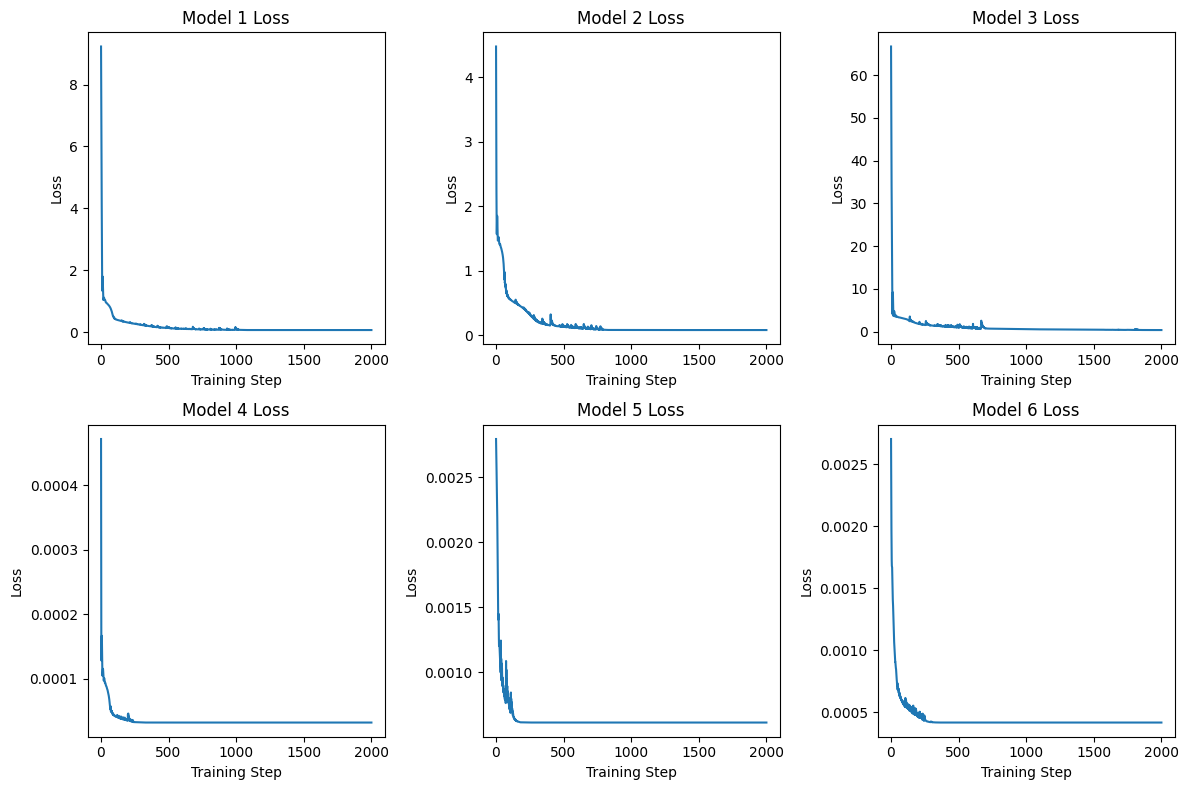

In [3]:
networks, all_losses, best_loss = train_indirect_model(
    data="free_space",
    network_architecture="lstm",
    arm="PSM1",
    data_root=r"..\Data",
    model_save_root=r"..\filtered_torque_colon_9_26",
    epochs=2000,
    batch_size=131072,
)

Test

In [3]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import utils
def run_prediction_from_paths(
    data_path,
    model_dir,
    output_file,
    epoch_to_use=0,
    attn_nhead=1,
):

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("device is:", device)

    data_path = Path(data_path)
    model_dir = Path(model_dir)
    output_file = Path(output_file)

    JOINTS = utils.JOINTS
    max_torque = torch.tensor(utils.max_torque).to(device)

    # Infer network type from model path
    model_parts = [p.lower() for p in model_dir.parts]

    if "lstm" in model_parts:
        net = "lstm"
    elif "attn" in model_parts:
        net = "attn"
    elif "ff" in model_parts:
        net = "ff"
    else:
        raise ValueError(
            "Cannot infer network type from model_dir. "
            "model_dir should contain lstm, attn, or ff in the path."
        )

    print("Detected network:", net)

    is_rnn = net != "ff"

    if is_rnn:
        batch_size = 1
        window = 1000
    else:
        batch_size = 8192
        window = utils.WINDOW

    in_joints = [0, 1, 2, 3, 4, 5]

    # -------------------------
    # Coordinate transform helper
    # -------------------------
    flip_y_axis = np.diag([-1.0, -1.0, 1.0])

    basis = np.array([
        [0, 0, -1],
        [0, 1, 0],
        [1, 0, 0]
    ], dtype=float)

    angle_z = np.deg2rad(-30)

    Rz_x = np.array([
        [np.cos(angle_z), -np.sin(angle_z), 0],
        [np.sin(angle_z),  np.cos(angle_z), 0],
        [0,                0,               1]
    ], dtype=float)

    Rx_minus_45 = np.array([
        [1,  0,       0],
        [0,  0.7071,  0.7071],
        [0, -0.7071,  0.7071]
    ], dtype=float)

    rotated = Rz_x @ Rx_minus_45 @ flip_y_axis
    T_transpose = np.linalg.inv(rotated) @ basis

    axis_correction = np.array([
        [0,  1, 0],
        [-1, 0, 0],
        [0,  0, 1]
    ], dtype=float)

    def apply_coord_transform(force_np):
        f = force_np @ T_transpose
        f = (axis_correction @ f.T).T
        return f

    # -------------------------
    # Dataset
    # -------------------------
    if is_rnn:
        dataset = indirectDataset(
            str(data_path),
            window,
            utils.SKIP,
            in_joints,
            is_rnn=is_rnn
        )
    else:
        dataset = indirectTestDataset(
            str(data_path),
            window,
            utils.SKIP,
            in_joints,
            is_rnn=is_rnn
        )

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    # -------------------------
    # Build networks
    # -------------------------
    networks = []

    for j in range(JOINTS):
        if net == "lstm":
            networks.append(
                torqueLstmNetwork(batch_size, device).to(device)
            )
        elif net == "attn":
            networks.append(
                torqueTransNetwork(
                    batch_size,
                    device,
                    attn_nhead=attn_nhead
                ).to(device)
            )
        else:
            networks.append(
                fsNetwork(window).to(device)
            )

    # -------------------------
    # Load models
    # model_dir should contain 0/, 1/, ..., 5/
    # -------------------------
    for j in range(JOINTS):
        cur_model_root = model_dir / str(j)

        if not cur_model_root.exists():
            raise FileNotFoundError(f"Model folder not found: {cur_model_root}")

        print("Loading model from:", cur_model_root)

        utils.load_prev(
            networks[j],
            cur_model_root,
            epoch_to_use
        )

        networks[j].eval()
        print(f"Loaded joint {j} model")

    # -------------------------
    # Prediction
    # -------------------------
    loss_fn = torch.nn.MSELoss()

    all_loss = 0.0
    all_pred = torch.tensor([])
    all_time = torch.tensor([])

    with torch.no_grad():
        for i, (position, velocity, torque, jacobian, time) in enumerate(loader):
            position = position.to(device)
            velocity = velocity.to(device)

            if is_rnn:
                posvel = torch.cat((position, velocity), axis=2).contiguous()
                time = time.permute((1, 0))
            else:
                posvel = torch.cat((position, velocity), axis=1).contiguous()

            torque = torque.squeeze()

            cur_pred = torch.zeros(torque.size())

            for j in range(JOINTS):
                pred = networks[j](posvel)
                pred = pred.squeeze().detach()
                pred = pred * max_torque[j]

                cur_pred[:, j] = pred.cpu()

            loss = loss_fn(cur_pred, torque.cpu())
            all_loss += loss.item()

            if is_rnn:
                time = time.squeeze(-1)

            all_time = torch.cat(
                (all_time, time.cpu()),
                axis=0
            ) if all_time.size() else time.cpu()

            all_pred = torch.cat(
                (all_pred, cur_pred.cpu()),
                axis=0
            ) if all_pred.size() else cur_pred.cpu()

    all_pred = torch.cat(
        (all_time.unsqueeze(1), all_pred),
        axis=1
    )

    output_file.parent.mkdir(parents=True, exist_ok=True)

    np.savetxt(
        output_file,
        all_pred.numpy(),
        delimiter=","
    )

    print("Saved prediction to:")
    print(output_file)
    print("Loss:", all_loss)

    return all_pred.numpy(), all_loss, apply_coord_transform

In [12]:
pred, loss, apply_coord_transform = run_prediction_from_paths(
    data_path=r"..\Data\val_csv",
    model_dir=r"..\filtered_torque_colon_9_26\lstm\PSM1\free_space",
    output_file=r"..\Data\val_csv\lstm_seal_pred_filtered_torque_colon_9_26.csv",
    epoch_to_use=0,
    attn_nhead=1,
)

device is: cuda:0
Detected network: lstm
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\0
Restored model, epoch 986
Loaded joint 0 model
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\1
Restored model, epoch 806
Loaded joint 1 model
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\2
Restored model, epoch 1841
Loaded joint 2 model
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\3
Restored model, epoch 186
Loaded joint 3 model
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\4
Restored model, epoch 71
Loaded joint 4 model
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\5
Restored model, epoch 196
Loaded joint 5 model
Saved prediction to:
..\Data\val_csv\lstm_seal_pred_filtered_torque_colon_9_26.csv
Loss: 3.77899781614542


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def plot_torque_from_paths(
    data_folder,
    pred_csv,
    fig_path=None,
    title="Torque Prediction",
):

    data_folder = Path(data_folder)
    pred_csv = Path(pred_csv)

    joint_csv = data_folder / "joints" / "interpolated_all_joints.csv"

    if fig_path is None:
        fig_path = data_folder / "torque_comparison.png"
    else:
        fig_path = Path(fig_path)

    # -------------------------
    # Load data
    # -------------------------
    joint_data = np.loadtxt(joint_csv, delimiter=",")
    pred_data = np.loadtxt(pred_csv, delimiter=",")

    # Time
    time_joint = joint_data[:, 0] - joint_data[0, 0]
    time_pred = pred_data[:, 0]

    # joint_data columns:
    # 0      = time
    # 1:7    = position
    # 7:13   = velocity
    # 13:19  = measured torque
    measured = joint_data[:, 13:19]

    # pred_data columns:
    # 0    = time
    # 1:7  = predicted torque
    predicted = pred_data[:, 1:7]

    # -------------------------
    # Align lengths
    # -------------------------
    N = min(len(time_pred), len(time_joint), len(measured), len(predicted))

    time_pred = time_pred[:N]
    measured = measured[:N]
    predicted = predicted[:N]

    rmse_per_joint = np.sqrt(np.mean((measured - predicted) ** 2, axis=0))
    rmse_overall = np.mean(rmse_per_joint)

    print(f"Overall RMSE: {rmse_overall:.4f}")
    for j in range(6):
        print(f"  Joint {j + 1}: {rmse_per_joint[j]:.4f}")

    # Plot
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 6),
        constrained_layout=True
    )

    fig.suptitle(f"{title}, RMSE = {rmse_overall:.4f}")

    for j, ax in enumerate(axes.flat):
        ax.plot(
            time_pred,
            measured[:, j],
            "b",
            label="measured",
            linewidth=0.8
        )

        ax.plot(
            time_pred,
            predicted[:, j],
            "r",
            label="predicted",
            linewidth=0.8
        )

        ax.set_title(f"Joint {j + 1}, RMSE = {rmse_per_joint[j]:.4f}")
        ax.set_xlabel("Time / s")
        ax.set_ylabel("Torque / Nm")
        ax.grid(True)

    axes[0, 0].legend(loc="upper right")

    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150)

    print("Plot saved to:")
    print(fig_path)

    plt.show()

    return rmse_per_joint, rmse_overall

Overall RMSE: 0.2369
  Joint 1: 0.2902
  Joint 2: 0.3195
  Joint 3: 0.7713
  Joint 4: 0.0051
  Joint 5: 0.0210
  Joint 6: 0.0143
Plot saved to:
..\Data\val_csv\lstm_torque_comparison.png


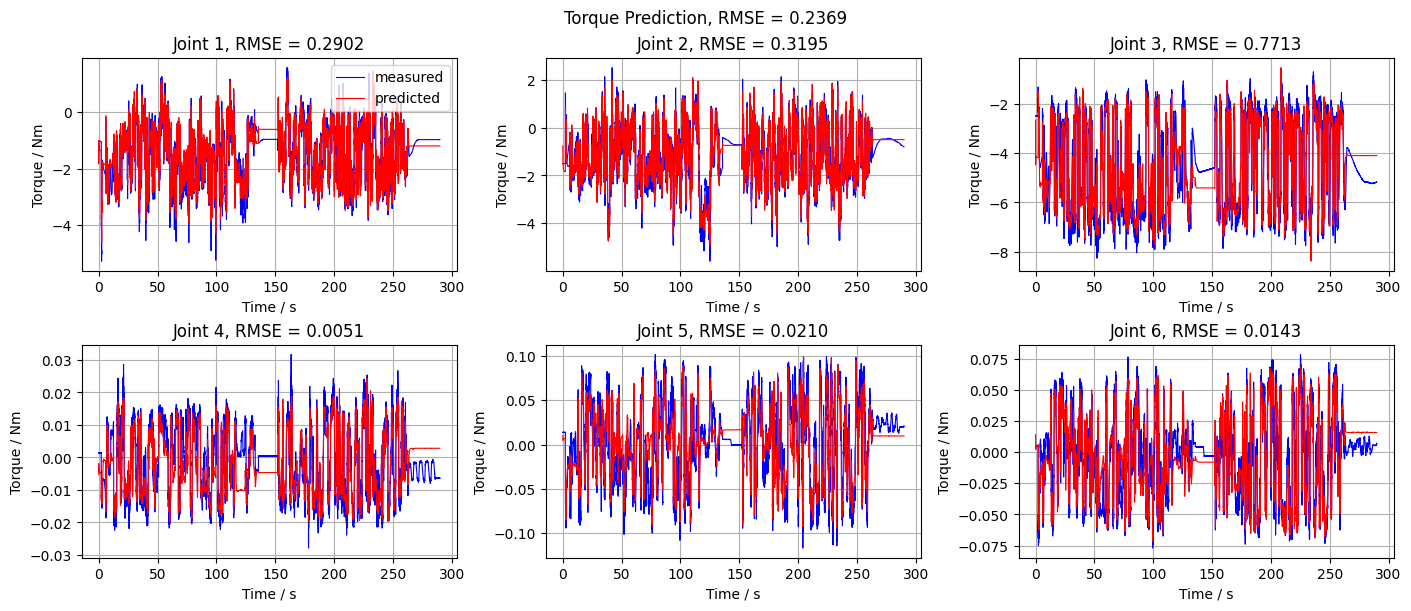

In [13]:
rmse_per_joint, rmse_overall = plot_torque_from_paths(
    data_folder=r"..\Data\val_csv",
    pred_csv=r"..\Data\val_csv\lstm_seal_pred_filtered_torque_colon_9_26.csv",
    fig_path=r"..\Data\val_csv\lstm_torque_comparison.png",
)

## Force Estimation

In [14]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from scipy import interpolate
from scipy.signal import lfilter


def run_force_estimation_from_paths(
    data_path,
    model_dir,
    output_prefix=None,
    epoch_to_use=0,
    angle_z_deg=-22,
    attn_nhead=1,
):
    """
    Parameters
    ----------
    data_path : str or Path
        Example:
            r"..\\Data\\test_csv"

        This folder should contain:
            joints/interpolated_all_joints.csv
            jacobian/interpolated_all_jacobian.csv
            sensor/interpolated_all_sensor.csv

    model_dir : str or Path
        Example:
            r"..\\filtered_torque_colon_9_26\\lstm\\PSM1\\free_space"

        This folder should contain:
            0/
            1/
            2/
            3/
            4/
            5/

    output_prefix : str or None
        Prefix for output files. If None, automatically uses network name.
    """

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("device is:", device)

    data_path = Path(data_path)
    model_dir = Path(model_dir)

    JOINTS = utils.JOINTS
    window = 1000
    batch_size = 1
    in_joints = [0, 1, 2, 3, 4, 5]

    max_torque = torch.tensor(utils.max_torque).to(device)

    # Infer net type from model path
    model_parts = [p.lower() for p in model_dir.parts]

    if "lstm" in model_parts:
        net = "lstm"
    elif "attn" in model_parts:
        net = "attn"
    elif "ff" in model_parts:
        net = "ff"
    else:
        raise ValueError(
            "Cannot infer network type from model_dir. "
            "The path should contain lstm, attn, or ff."
        )

    if output_prefix is None:
        output_prefix = net

    print("Detected network:", net)
    print("Data path:", data_path)
    print("Model dir:", model_dir)

    # -------------------------
    # Coordinate transform
    # -------------------------
    flip_y_axis = np.diag([-1.0, -1.0, 1.0])

    basis = np.array([
        [0, 0, -1],
        [0, 1, 0],
        [1, 0, 0]
    ], dtype=float)

    angle_z = np.deg2rad(angle_z_deg)

    Rz_x = np.array([
        [np.cos(angle_z), -np.sin(angle_z), 0],
        [np.sin(angle_z),  np.cos(angle_z), 0],
        [0,                0,               1]
    ], dtype=float)

    Rx_minus_45 = np.array([
        [1,  0,       0],
        [0,  0.7071,  0.7071],
        [0, -0.7071,  0.7071]
    ], dtype=float)

    rotated = Rz_x @ Rx_minus_45 @ flip_y_axis
    T_transpose = np.linalg.inv(rotated) @ basis

    axis_correction = np.array([
        [0,  1, 0],
        [-1, 0, 0],
        [0,  0, 1]
    ], dtype=float)

    def apply_coord_transform(force_np):
        """
        Apply robot -> sensor coordinate transform to force columns.
        force_np shape: (N, 3)
        """
        f = force_np @ T_transpose
        f = (axis_correction @ f.T).T
        return f

    # -------------------------
    # Dataset
    # -------------------------
    dataset = indirectDataset(
        str(data_path),
        window,
        utils.SKIP,
        in_joints,
        is_rnn=True
    )

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    # -------------------------
    # Build and load networks
    # -------------------------
    networks = []

    for j in range(JOINTS):
        if net == "lstm":
            network = torqueLstmNetwork(batch_size, device).to(device)

        elif net == "attn":
            network = torqueTransNetwork(
                batch_size,
                device,
                attn_nhead=attn_nhead
            ).to(device)

        else:
            network = fsNetwork(window).to(device)

        cur_model_root = model_dir / str(j)

        if not cur_model_root.exists():
            raise FileNotFoundError(f"Model folder not found: {cur_model_root}")

        print("Loading model from:", cur_model_root)

        utils.load_prev(
            network,
            cur_model_root,
            epoch_to_use
        )

        network.eval()
        networks.append(network)

        print("Loaded model", j)

    # -------------------------
    # Predict torque residual and calculate force
    # -------------------------
    all_diff = torch.tensor([])
    all_jacobian = torch.tensor([])
    all_time = torch.tensor([])

    with torch.no_grad():
        for position, velocity, torque, jacobian, time in loader:
            position = position.to(device)
            velocity = velocity.to(device)

            posvel = torch.cat(
                (position, velocity),
                axis=2
            ).contiguous()

            time = time.permute((1, 0)).squeeze(-1)   # (window,)
            torque = torque.squeeze(0)                # (window, 6)
            jacobian = jacobian.squeeze(0)            # (window, 36)

            step_pred = torch.zeros(torque.size())

            for j in range(JOINTS):
                pred = networks[j](posvel)
                pred = pred.squeeze().detach()
                pred = pred * max_torque[j]

                step_pred[:, j] = pred.cpu()

            # torque residual: measured torque - predicted torque
            diff = torque - step_pred

            all_diff = torch.cat(
                (all_diff, diff),
                axis=0
            ) if all_diff.size() else diff

            all_jacobian = torch.cat(
                (all_jacobian, jacobian),
                axis=0
            ) if all_jacobian.size() else jacobian

            all_time = torch.cat(
                (all_time, time.cpu()),
                axis=0
            ) if all_time.size() else time.cpu()

    # -------------------------
    # Calculate force from Jacobian and residual torque
    # -------------------------
    all_force_t = utils.calculate_force(all_jacobian, all_diff)  # (N, 6)
    all_force_np = all_force_t.numpy().copy()

    # Coordinate transform on force columns only
    all_force_np[:, :3] = apply_coord_transform(all_force_np[:, :3])

    # Moving average filter
    b = (1.0 / 50) * np.ones(50)
    all_force_np = lfilter(b, [1.0], all_force_np, axis=0)

    pred_time = all_time.numpy()

    # -------------------------
    # Save predicted force
    # -------------------------
    result = np.hstack([
        pred_time[:, None],
        all_force_np
    ])

    force_csv = data_path / f"{output_prefix}_force.csv"

    np.savetxt(
        force_csv,
        result,
        delimiter=","
    )

    print("Predicted force saved to:")
    print(force_csv)

    # -------------------------
    # Load ground truth force sensor
    # -------------------------
    sensor_csv = data_path / "sensor" / "interpolated_all_sensor.csv"

    if not sensor_csv.exists():
        print("Sensor CSV not found. Skip RMSE and comparison plot.")
        print("Missing:", sensor_csv)
        return result, None

    sensor_data = np.loadtxt(sensor_csv, delimiter=",")

    sensor_time = sensor_data[:, 0]
    sensor_force = sensor_data[:, 1:4]  # Fx, Fy, Fz

    # -------------------------
    # Align to common time range
    # -------------------------
    t_start = max(pred_time[0], sensor_time[0])
    t_end = min(pred_time[-1], sensor_time[-1])

    mask = (pred_time >= t_start) & (pred_time <= t_end)

    pred_time_aligned = pred_time[mask]
    pred_force_aligned = all_force_np[mask, :3]

    sensor_interp = np.zeros((mask.sum(), 3))

    for i in range(3):
        f = interpolate.interp1d(
            sensor_time,
            sensor_force[:, i],
            bounds_error=False,
            fill_value="extrapolate"
        )
        sensor_interp[:, i] = f(pred_time_aligned)

    # -------------------------
    # RMSE
    # -------------------------
    rmse = np.sqrt(
        np.mean(
            (pred_force_aligned - sensor_interp) ** 2,
            axis=0
        )
    )

    labels = ["Fx", "Fy", "Fz"]

    print("\nForce RMSE (N):")
    for k, lb in enumerate(labels):
        print(f"  {lb}: {rmse[k]:.4f}")

    print(f"  mean: {np.mean(rmse):.4f}")

    # -------------------------
    # Save comparison CSV
    # columns:
    # time, pred_Fx, pred_Fy, pred_Fz, measured_Fx, measured_Fy, measured_Fz
    # -------------------------
    comparison = np.hstack([
        pred_time_aligned[:, None],
        pred_force_aligned,
        sensor_interp
    ])

    comparison_csv = data_path / f"{output_prefix}_force_comparison.csv"

    np.savetxt(
        comparison_csv,
        comparison,
        delimiter=","
    )

    print("Comparison saved to:")
    print(comparison_csv)

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 8),
        constrained_layout=True
    )

    fig.suptitle(f"Force Estimation ({net.upper()})")

    for k, ax in enumerate(axes):
        ax.plot(
            pred_time_aligned,
            sensor_interp[:, k],
            "b",
            label="measured"
        )

        ax.plot(
            pred_time_aligned,
            pred_force_aligned[:, k],
            "r",
            label="predicted"
        )

        ax.set_title(f"{labels[k]}, RMSE = {rmse[k]:.4f}")
        ax.set_ylabel("Force / N")
        ax.grid(True)

    axes[-1].set_xlabel("Time / s")
    axes[0].legend(loc="upper right")

    fig_path = data_path / f"{output_prefix}_force_comparison.png"

    plt.savefig(
        fig_path,
        dpi=150
    )

    print("Plot saved to:")
    print(fig_path)

    plt.show()

    return result, rmse

device is: cuda:0
Detected network: lstm
Data path: ..\Data\test_csv
Model dir: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\0
Restored model, epoch 986
Loaded model 0
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\1
Restored model, epoch 806
Loaded model 1
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\2
Restored model, epoch 1841
Loaded model 2
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\3
Restored model, epoch 186
Loaded model 3
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\4
Restored model, epoch 71
Loaded model 4
Loading model from: ..\filtered_torque_colon_9_26\lstm\PSM1\free_space\5
Restored model, epoch 196
Loaded model 5
Predicted force saved to:
..\Data\test_csv\lstm_force.csv

Force RMSE (N):
  Fx: 3.4257
  Fy: 3.3776
  Fz: 4.4471
  mean: 3.7501
Comparison saved to:
..\Data\test_csv\lstm_force_compari

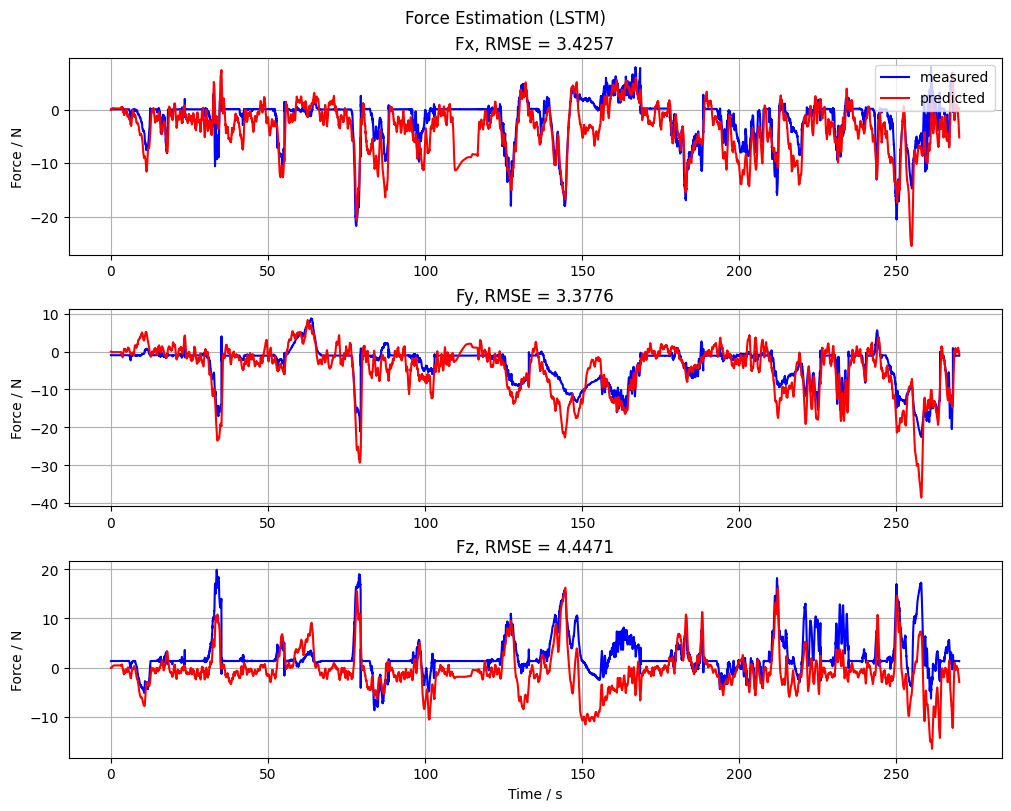

In [15]:
force_result, rmse = run_force_estimation_from_paths(
    data_path=r"..\Data\test_csv",
    model_dir=r"..\filtered_torque_colon_9_26\lstm\PSM1\free_space",
)